In [4]:
import numpy
import pandas
import matplotlib
import seaborn
import sklearn
import jupyter

print("Semua library berhasil diimpor!")

from sklearn.datasets import load_iris
iris = load_iris()
print(iris.DESCR)

Semua library berhasil diimpor!
.. _iris_dataset:

Iris plants dataset
--------------------

**Data Set Characteristics:**

:Number of Instances: 150 (50 in each of three classes)
:Number of Attributes: 4 numeric, predictive attributes and the class
:Attribute Information:
    - sepal length in cm
    - sepal width in cm
    - petal length in cm
    - petal width in cm
    - class:
            - Iris-Setosa
            - Iris-Versicolour
            - Iris-Virginica

:Summary Statistics:

============== ==== ==== ======= ===== ====================
                Min  Max   Mean    SD   Class Correlation
============== ==== ==== ======= ===== ====================
sepal length:   4.3  7.9   5.84   0.83    0.7826
sepal width:    2.0  4.4   3.05   0.43   -0.4194
petal length:   1.0  6.9   3.76   1.76    0.9490  (high!)
petal width:    0.1  2.5   1.20   0.76    0.9565  (high!)
============== ==== ==== ======= ===== ====================

:Missing Attribute Values: None
:Class Distribution: 

In [50]:
# Library dasar untuk data dan matematika
import numpy as np
import pandas as pd

# Library untuk visualisasi
import matplotlib.pyplot as plt
import seaborn as sns

# Library machine learning dari scikit-learn
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.tree import DecisionTreeClassifier

In [7]:
# Memuat dataset Iris
iris = load_iris()
X = iris.data      # fitur: panjang & lebar kelopak, panjang & lebar mahkota
y = iris.target    # label: 0 = setosa, 1 = versicolor, 2 = virginica

# Melihat nama fitur dan label
print("Nama fitur:", iris.feature_names)
print("Nama kelas:", iris.target_names)
print("Jumlah sampel:", len(X))

Nama fitur: ['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']
Nama kelas: ['setosa' 'versicolor' 'virginica']
Jumlah sampel: 150


In [8]:
# Ubah ke DataFrame agar lebih mudah dibaca
df = pd.DataFrame(X, columns=iris.feature_names)
df['species'] = pd.Categorical.from_codes(y, iris.target_names)

# Tampilkan 5 baris pertama
df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


In [9]:
# Statistik ringkas
df.describe()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
count,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.057333,3.758000,1.199333
std,0.828066,0.435866,1.765298,0.762238
min,4.300000,2.000000,1.000000,0.100000
25%,5.100000,2.800000,1.600000,0.300000
50%,5.800000,3.000000,4.350000,1.300000
75%,6.400000,3.300000,5.100000,1.800000
max,7.900000,4.400000,6.900000,2.500000


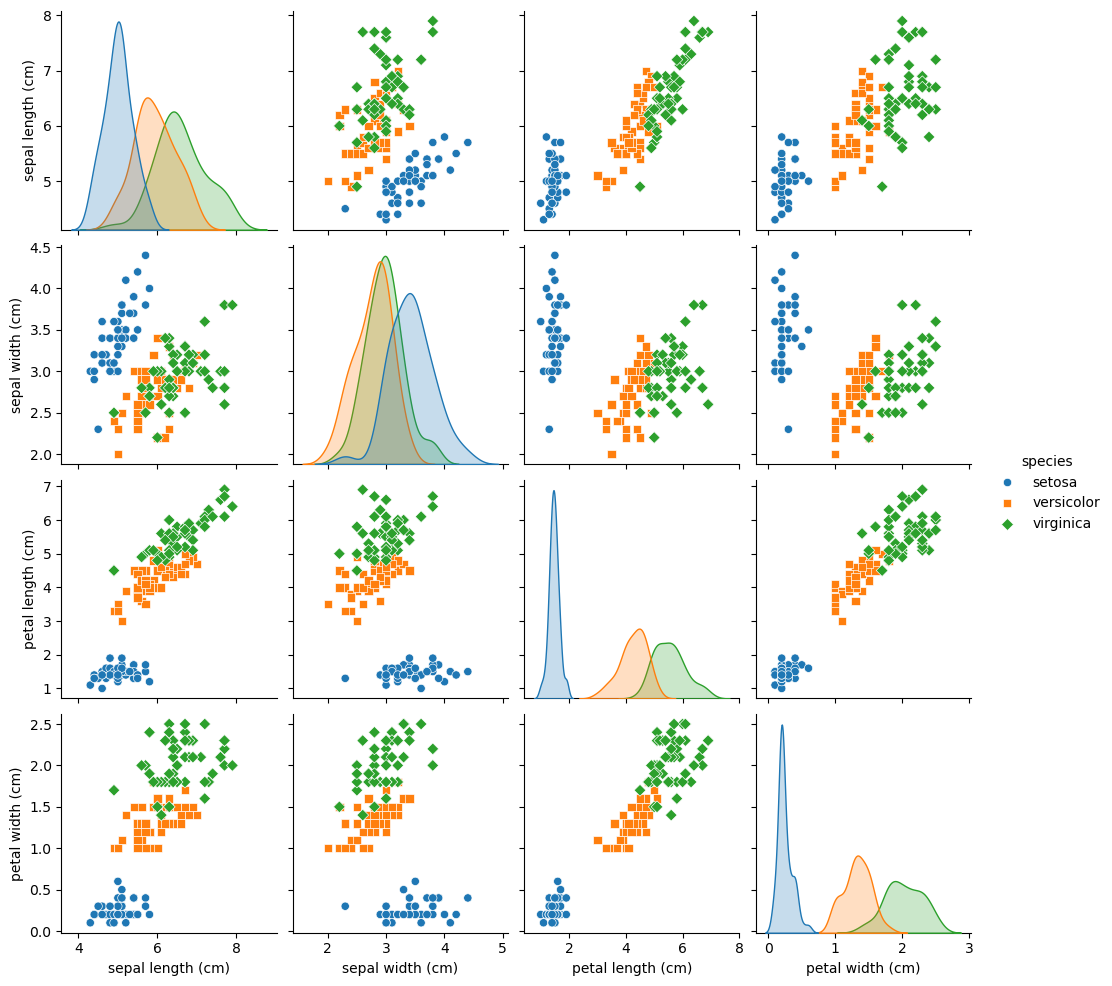

In [10]:
# Visualisasi sebaran fitur
sns.pairplot(df, hue='species', markers=['o','s','D'])
plt.show()

In [11]:
# Split 80% untuk training, 20% untuk testing
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Data latih:", X_train.shape[0], "sampel")
print("Data uji  :", X_test.shape[0], "sampel")

Data latih: 120 sampel
Data uji  : 30 sampel


In [30]:
# Membuat model KNN
model = KNeighborsClassifier(n_neighbors=3)

In [31]:
# Latih model dengan data latih
model.fit(X_train, y_train)
print("Model selesai dilatih!")

Model selesai dilatih!


In [32]:
# Prediksi kelas untuk data uji
y_pred = model.predict(X_test)

# Lihat 10 prediksi pertama
print("Prediksi   :", y_pred[:10])
print("Nilai asli :", y_test[:10])

Prediksi   : [1 0 2 1 1 0 1 2 1 1]
Nilai asli : [1 0 2 1 1 0 1 2 1 1]


In [33]:
# Akurasi
akurasi = accuracy_score(y_test, y_pred)
print(f"Akurasi: {akurasi*100:.2f}%")

Akurasi: 100.00%


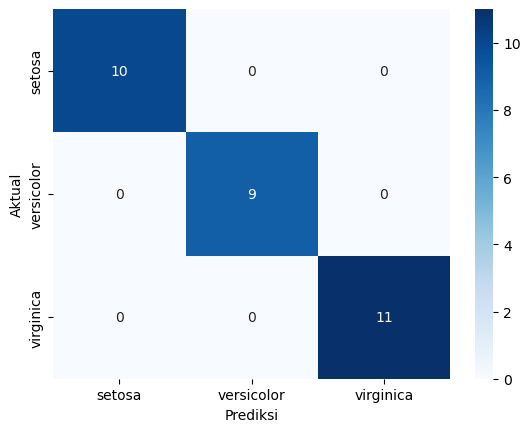

In [16]:
# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, xticklabels=iris.target_names, yticklabels=iris.target_names, cmap='Blues')
plt.xlabel('Prediksi')
plt.ylabel('Aktual')
plt.show()

In [17]:
# Laporan lengkap
print(classification_report(y_test, y_pred, target_names=iris.target_names))

              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      1.00      1.00         9
   virginica       1.00      1.00      1.00        11

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30



In [18]:
# Misal kita dapat bunga baru dengan ukuran:
bunga_baru = [[5.1, 3.5, 1.4, 0.2]]  # sepal length, sepal width, petal length, petal width

prediksi = model.predict(bunga_baru)
print("Prediksi spesies:", iris.target_names[prediksi][0])

Prediksi spesies: setosa


In [45]:
# Membuat model KNN
model = KNeighborsClassifier(n_neighbors=7)

In [46]:
# Latih model dengan data latih
model.fit(X_train, y_train)
print("Model selesai dilatih!")

Model selesai dilatih!


In [47]:
# Prediksi kelas untuk data uji
y_pred = model.predict(X_test)

# Lihat 10 prediksi pertama
print("Prediksi   :", y_pred[:10])
print("Nilai asli :", y_test[:10])

Prediksi   : [1 0 2 1 1 0 1 2 2 1]
Nilai asli : [1 0 2 1 1 0 1 2 1 1]


In [48]:
# Akurasi
akurasi = accuracy_score(y_test, y_pred)
print(f"Akurasi: {akurasi*100:.2f}%")

Akurasi: 96.67%


In [51]:
model = DecisionTreeClassifier(random_state=42)

In [52]:
# Latih model dengan data latih
model.fit(X_train, y_train)
print("Model selesai dilatih!")

Model selesai dilatih!


In [53]:
# Prediksi kelas untuk data uji
y_pred = model.predict(X_test)

# Lihat 10 prediksi pertama
print("Prediksi   :", y_pred[:10])
print("Nilai asli :", y_test[:10])

Prediksi   : [1 0 2 1 1 0 1 2 1 1]
Nilai asli : [1 0 2 1 1 0 1 2 1 1]


In [54]:
# Akurasi
akurasi = accuracy_score(y_test, y_pred)
print(f"Akurasi: {akurasi*100:.2f}%")

Akurasi: 100.00%


In [55]:
from sklearn.datasets import load_wine

# Memuat dataset Wine
wine = load_wine()
X = wine.data      # fitur kimia wine (alkohol, malic acid, dll)
y = wine.target    # label kelas wine (0, 1, atau 2)

# Melihat nama fitur dan label
print("Nama fitur:", wine.feature_names)
print("Nama kelas:", wine.target_names)
print("Jumlah sampel:", len(X))

Nama fitur: ['alcohol', 'malic_acid', 'ash', 'alcalinity_of_ash', 'magnesium', 'total_phenols', 'flavanoids', 'nonflavanoid_phenols', 'proanthocyanins', 'color_intensity', 'hue', 'od280/od315_of_diluted_wines', 'proline']
Nama kelas: ['class_0' 'class_1' 'class_2']
Jumlah sampel: 178


In [56]:
from sklearn.datasets import load_diabetes

# Memuat dataset Diabetes
diabetes = load_diabetes()
X = diabetes.data    # fitur: age, sex, bmi, bp, dll
y = diabetes.target  # label: nilai kontinu (progres penyakit)

# Melihat nama fitur (Dataset diabetes tidak punya target_names karena berupa angka kontinu)
print("Nama fitur:", diabetes.feature_names)
print("Jumlah sampel:", len(X))
print("Contoh 5 nilai target pertama:", y[:5])

Nama fitur: ['age', 'sex', 'bmi', 'bp', 's1', 's2', 's3', 's4', 's5', 's6']
Jumlah sampel: 442
Contoh 5 nilai target pertama: [151.  75. 141. 206. 135.]


                               alcohol  malic_acid       ash  \
alcohol                       1.000000    0.094397  0.211545   
malic_acid                    0.094397    1.000000  0.164045   
ash                           0.211545    0.164045  1.000000   
alcalinity_of_ash            -0.310235    0.288500  0.443367   
magnesium                     0.270798   -0.054575  0.286587   
total_phenols                 0.289101   -0.335167  0.128980   
flavanoids                    0.236815   -0.411007  0.115077   
nonflavanoid_phenols         -0.155929    0.292977  0.186230   
proanthocyanins               0.136698   -0.220746  0.009652   
color_intensity               0.546364    0.248985  0.258887   
hue                          -0.071747   -0.561296 -0.074667   
od280/od315_of_diluted_wines  0.072343   -0.368710  0.003911   
proline                       0.643720   -0.192011  0.223626   
target                       -0.328222    0.437776 -0.049643   

                              alcalinit

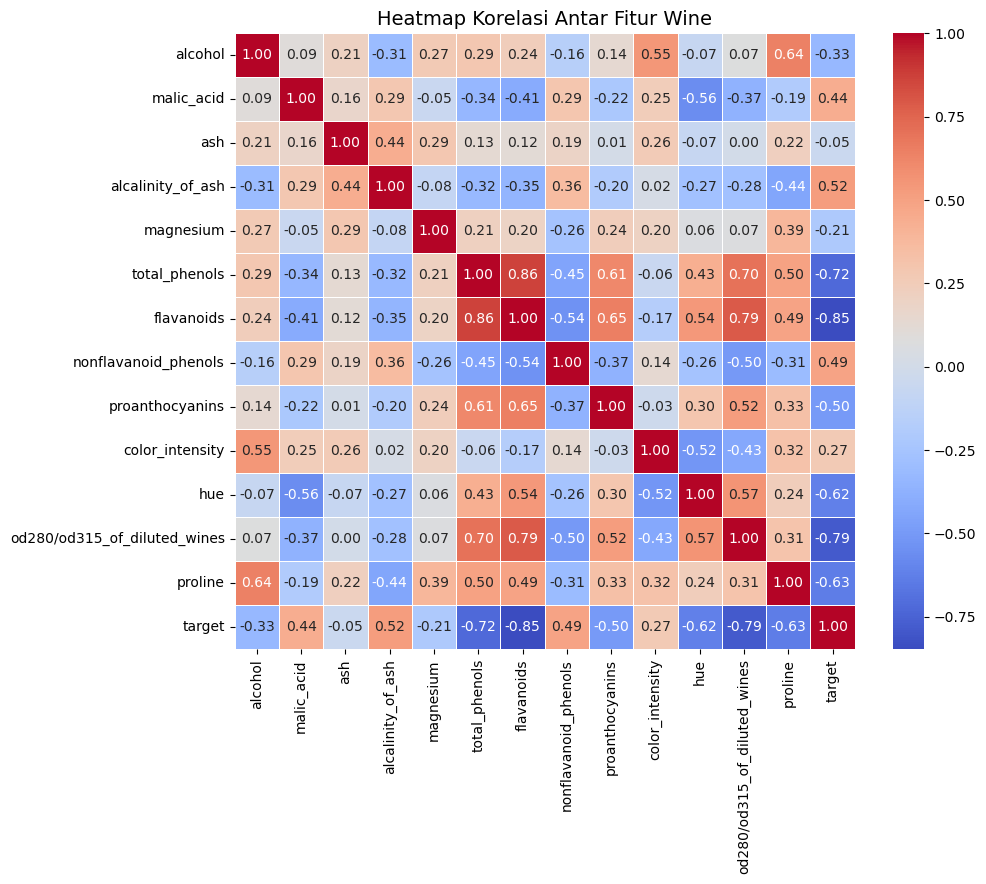

In [57]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Ubah dataset menjadi Pandas DataFrame (misalnya menggunakan dataset Wine)
from sklearn.datasets import load_wine
wine = load_wine()

df = pd.DataFrame(wine.data, columns=wine.feature_names)
df['target'] = wine.target # Masukkan kolom target/label ke dalam DataFrame

# 2. Hitung matriks korelasi antar fitur
correlation_matrix = df.corr()

# Tampilkan tabel korelasi teks
print(correlation_matrix)

# 3. Visualisasikan korelasi agar lebih mudah dibaca (Heatmap)
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title("Heatmap Korelasi Antar Fitur Wine", fontsize=14)
plt.show()